In [ ]:
# installing the libraries
!pip install nltk
!pip install wordcloud
!pip install gensim
!pip install keras
!pip install tensorflow
!pip install seaborn

Loading Datasets and Creating Dataframe

In [ ]:
# importing the libraries
import nltk
nltk.download('punkt')

import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
# importing libraries
import pandas as pd
import numpy as np

true_df = pd.read_csv("True.csv")
fake_df = pd.read_csv("Fake.csv")

In [ ]:
# display true dataset
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
# display fake dataset
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


Data Visualization

/tmp/ipython-input-2961056756.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="subject", palette="hls", data=true_df).set_title('True News Subject Distribution')


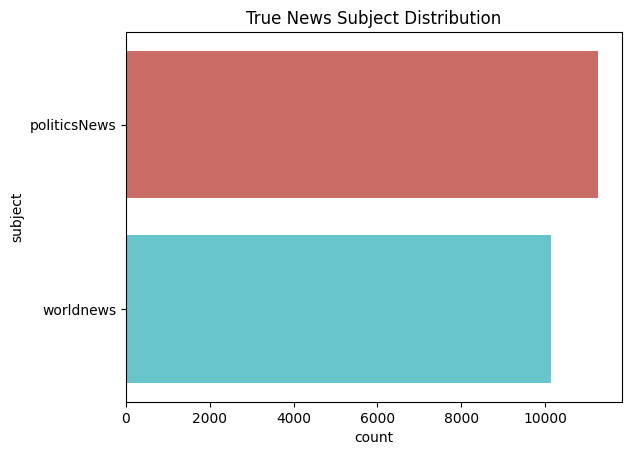

/tmp/ipython-input-2961056756.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="subject", palette="hls", data=fake_df).set_title('Fake News Subject Distribution')


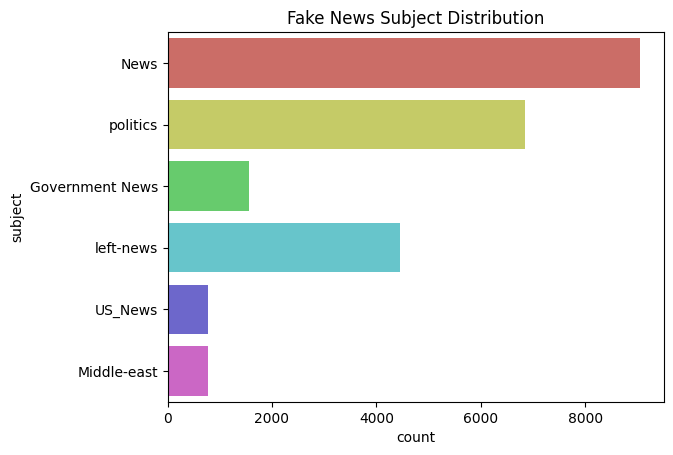

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(y="subject", palette="hls", data=true_df).set_title('True News Subject Distribution')
plt.show()

sns.countplot(y="subject", palette="hls", data=fake_df).set_title('Fake News Subject Distribution')
plt.show()

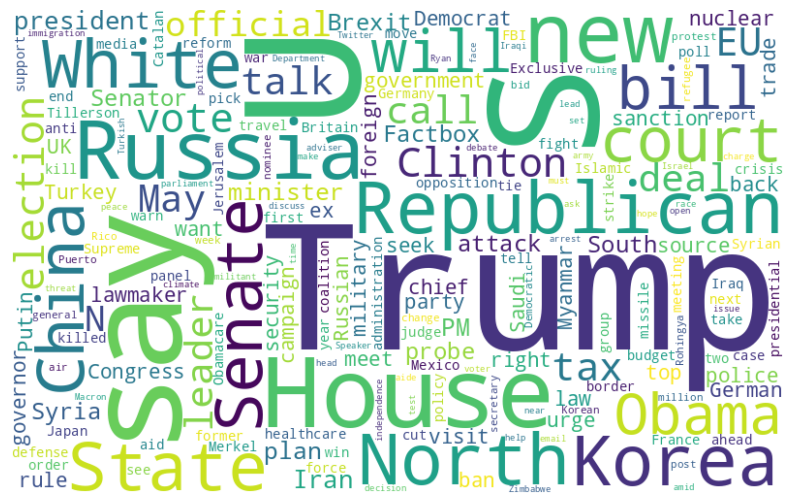

In [ ]:
# true news word cloud
from wordcloud import WordCloud

real_titles = true_df.title
real_titles_ls = [text for text in real_titles]
# print(alls)
real_all_words = ' '.join(real_titles)
wordcloud_real = WordCloud(background_color='white',
    width= 800, height= 500,
    max_font_size = 180,
    collocations = False).generate(real_all_words)

plt.figure(figsize=(10,7))
plt.imshow(wordcloud_real, interpolation='bilinear')
plt.axis("off")
plt.show()


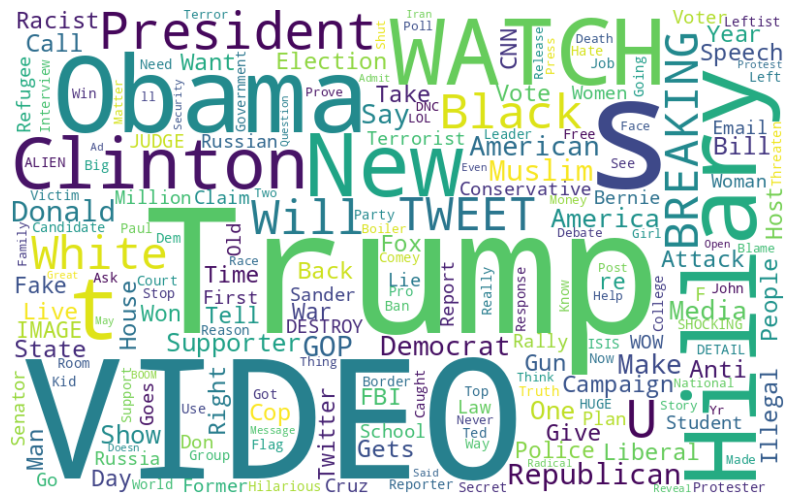

In [ ]:
fake_titles = fake_df.title
fake_titles_ls = [text for text in fake_titles]
# print(alls)
fake_all_words = ' '.join(fake_titles)
wordcloud_fake = WordCloud(background_color='white',
    width= 800, height= 500,
    max_font_size = 180,
    collocations = False).generate(fake_all_words)

plt.figure(figsize=(10,7))
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.axis("off")
plt.show()

Data Pre Processing

In [ ]:
# add label column to both df
true_df['true'] = 1
fake_df['true'] = 0

# Concate both the datasets
df = pd.concat([true_df, fake_df])
display(df)


,title,text,subject,date,true
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1
...,...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0


In [ ]:
# inspecting the news headlines

titles = [text for text in df.title]

max_len = 0
titles_len = []
for title in titles:
    titles_len.append(len(title.split()))
    max_len = max(len(title.split()), max_len)

print('Number of titles:', len(titles))
print('Max length of the titles:', max_len)
print('Mean length of the titles:', np.mean(titles_len))

Number of titles: 44898
Max length of the titles: 42
Mean length of the titles: 12.453472315025168


/tmp/ipython-input-194261629.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.countplot(x=titles_len, palette="hls")
/tmp/ipython-input-194261629.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=50)


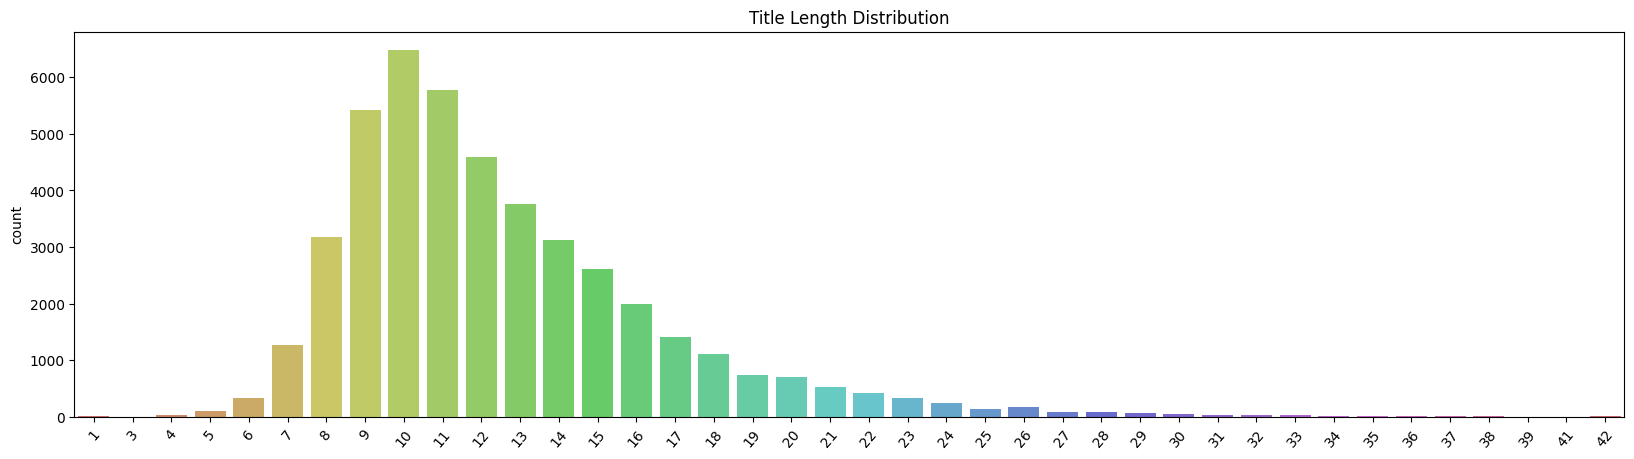

In [ ]:
# visualizing the title variable
plt.figure(figsize=(20,5))
g = sns.countplot(x=titles_len, palette="hls")
g.set_title('Title Length Distribution')
g.set_xticklabels(g.get_xticklabels(), rotation=50)
plt.show()

In [ ]:
# mean length of the texts
texts = [text for text in df.text]

max_len = 0
texts_len = []
for text in texts:
    texts_len.append(len(text.split()))
    max_len = max(len(text.split()), max_len)

# g = sns.countplot(x=texts_len)
print('Mean length of the texts:', np.mean(texts_len))

Mean length of the texts: 405.28228428883244


In [ ]:
# removing irrelevant columns and shuffling the dataset
from sklearn.utils import shuffle

# Purify
df = df.iloc[:,[0, -1]]

# Shuffle
df = shuffle(df).reset_index(drop=True)

display(df)




,title,true
0,Settlement proposed in North Carolina transgen...,1
1,WHOA! RAPE VICTIM RIPS INTO HILLARY For Enabli...,0
2,WATCH: Even CNN Admits Tax Bill That “Not One ...,0
3,BREAKING: Michael Flynn Resigns as Trump’s Nat...,0
4,Social Media Rips Republicans A New One For A...,0
...,...,...
44893,Syria rejects report blaming it for April sari...,1
44894,Trump nominates Columbia professor Jackson for...,1
44895,BREAKING: TRUMP MAKES HUGE ANNOUNCEMENT On Ame...,0
44896,Syrian army fights to secure corridor into Dei...,1


In [ ]:
# splitting dataset into train, validation and test
train_val_df = df.sample(frac = 0.8)
test_df = df.drop(train_val_df.index)

train_df = train_val_df.sample(frac = 0.8)
val_df = train_val_df.drop(train_df.index)

# Reset Index
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('trainset size:', train_df.shape)
print('valset size:', val_df.shape)
print('testset size:', test_df.shape)

trainset size: (28734, 2)
valset size: (7184, 2)
testset size: (8980, 2)


In [ ]:
# dataframe to csv
train_df.to_csv('train.tsv', sep='\t', index=False)
val_df.to_csv('val.tsv', sep='\t', index=False)
test_df.to_csv('test.tsv', sep='\t', index=False)

In [ ]:
df = pd.concat([train_df, val_df, test_df])
df

,title,true
0,Congressional Black Caucus Signals That They ...,0
1,Factbox: Republican side-deals build support f...,1
2,CNN’s Don Lemon: Trump Shouldn’t Get Apology ...,0
3,Trump says sets measure to punish companies th...,1
4,RACIST RANT From Supreme Court Justice Exposes...,0
...,...,...
8975,Virginia governor's bid to restore felon votin...,1
8976,U.S.-backed Syrian forces seize Raqqa mosque: ...,1
8977,Syria rejects report blaming it for April sari...,1
8978,BREAKING: TRUMP MAKES HUGE ANNOUNCEMENT On Ame...,0


In [ ]:
# data cleaning
import nltk
# Downloading Stopwords
nltk.download("stopwords")
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 're', 'edu', 'use'])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Removing Stopwords And Remove Words With 2 Or Less Characters
def preprocess(text):
    result = []
    for token in gensim.utils.simple_preprocess(text):
        if token not in gensim.parsing.preprocessing.STOPWORDS and len(token) > 3 and token not in stop_words:
            result.append(token)

    return result

In [ ]:
import gensim

# Applying The Function To The Dataframe
df['clean'] = df['title'].apply(preprocess)

In [ ]:
df

,title,true,clean
0,Congressional Black Caucus Signals That They ...,0,"[congressional, black, caucus, signals, absolu..."
1,Factbox: Republican side-deals build support f...,1,"[factbox, republican, deals, build, support, s..."
2,CNN’s Don Lemon: Trump Shouldn’t Get Apology ...,0,"[lemon, trump, apology, espn, apologizes, raci..."
3,Trump says sets measure to punish companies th...,1,"[trump, says, sets, measure, punish, companies..."
4,RACIST RANT From Supreme Court Justice Exposes...,0,"[racist, rant, supreme, court, justice, expose..."
...,...,...,...
8975,Virginia governor's bid to restore felon votin...,1,"[virginia, governor, restore, felon, voting, r..."
8976,U.S.-backed Syrian forces seize Raqqa mosque: ...,1,"[backed, syrian, forces, seize, raqqa, mosque,..."
8977,Syria rejects report blaming it for April sari...,1,"[syria, rejects, report, blaming, april, sarin..."
8978,BREAKING: TRUMP MAKES HUGE ANNOUNCEMENT On Ame...,0,"[breaking, trump, makes, huge, announcement, a..."


In [ ]:
# total words in the dataset
list_of_words = []
for i in df.clean:
    for j in i:
        list_of_words.append(j)

total_words = len(list(set(list_of_words)))
total_words

19174

tokenization and padding

In [ ]:
from nltk import word_tokenize

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Creating A Tokenizer To Tokenize The Words And Create Sequences Of Tokenized Words
tokenizer = Tokenizer(num_words = total_words)
tokenizer.fit_on_texts(train_df['title'])

train_sequences = tokenizer.texts_to_sequences(train_df['title'])
val_sequences = tokenizer.texts_to_sequences(val_df['title'])
test_sequences = tokenizer.texts_to_sequences(test_df['title'])

In [ ]:
len(train_sequences)

28734

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Adding Padding
padded_train = pad_sequences(train_sequences,maxlen = 42, padding = 'post', truncating = 'post')
padded_val = pad_sequences(val_sequences,maxlen = 42, padding = 'post', truncating = 'post')
padded_test = pad_sequences(test_sequences,maxlen = 42, padding = 'post', truncating = 'post')


# Model Building

In [ ]:
# LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Embedding, Input, LSTM, Conv1D, MaxPool1D, Bidirectional, Dropout, BatchNormalization

## Creating model Using LSTM
embedding_vector_features=40
model=Sequential()
model.add(Embedding(total_words,embedding_vector_features))
model.add(Dropout(0.5))
model.add(LSTM(64))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.build(input_shape=(None, padded_train.shape[1]))
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 42, 40)         │       766,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 42, 40)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        26,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 793,905 (3.03 MB)

 Trainable params: 793,905 (3.03 MB)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/3
449/449 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.6619 - loss: 0.5187 - val_accuracy: 0.9646 - val_loss: 0.0950
Epoch 2/3
449/449 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.9748 - loss: 0.0785 - val_accuracy: 0.9704 - val_loss: 0.0810
Epoch 3/3
449/449 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.9854 - loss: 0.0465 - val_accuracy: 0.9698 - val_loss: 0.0834


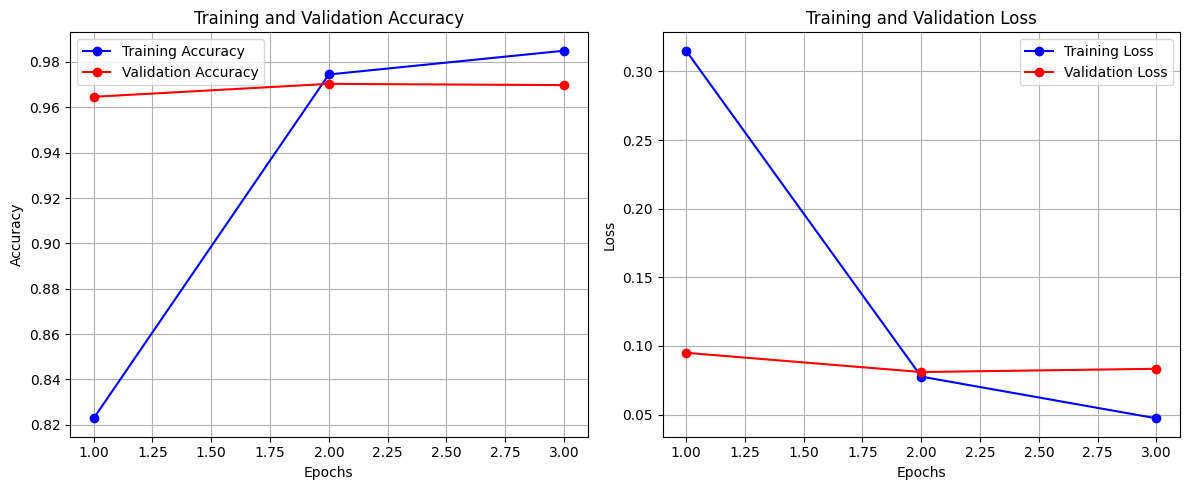

In [ ]:
y_train = np.asarray(train_df['true'])
y_val = np.asarray(val_df['true'])

# Training the model
# Training the model and storing the history
history = model.fit(padded_train, y_train, batch_size = 64, validation_data=(padded_val, y_val), epochs = 3)

# Get the history data
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_accuracy) + 1)

# Plot Training and Validation Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracy, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------

281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
LSTM Model Accuracy :  0.9668151447661469
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      4706
           1       0.97      0.96      0.96      4274

    accuracy                           0.97      8980
   macro avg       0.97      0.97      0.97      8980
weighted avg       0.97      0.97      0.97      8980



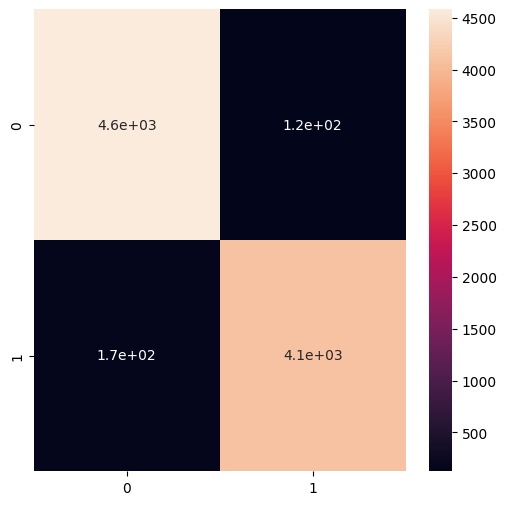

In [ ]:
# Making prediction
pred = model.predict(padded_test)
prediction = []
for i in pred:
    if i >= 0.5:
        prediction.append(1)
    else:
        prediction.append(0)
# Getting The Accuracy
from sklearn.metrics import accuracy_score
y_test = np.asarray(test_df['true'])

accuracy = accuracy_score(list(y_test), prediction)

print("LSTM Model Accuracy : ", accuracy)


# Getting The Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(list(y_test), prediction)
plt.figure(figsize = (6, 6))
sns.heatmap(cm, annot = True)

from sklearn.metrics import classification_report
print(classification_report(y_test, prediction))


In [ ]:
# building bidirectional LSTM model
embedding_vector_features=40
model=Sequential()
model.add(Embedding(total_words,embedding_vector_features))
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.build(input_shape=(None, padded_train.shape[1]))

print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 42, 40)         │       766,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 42, 40)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        53,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,849 (3.13 MB)

 Trainable params: 820,849 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/3
449/449 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.8299 - loss: 0.3550 - val_accuracy: 0.9603 - val_loss: 0.0991
Epoch 2/3
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.9776 - loss: 0.0683 - val_accuracy: 0.9720 - val_loss: 0.0742
Epoch 3/3
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.9867 - loss: 0.0376 - val_accuracy: 0.9747 - val_loss: 0.0735


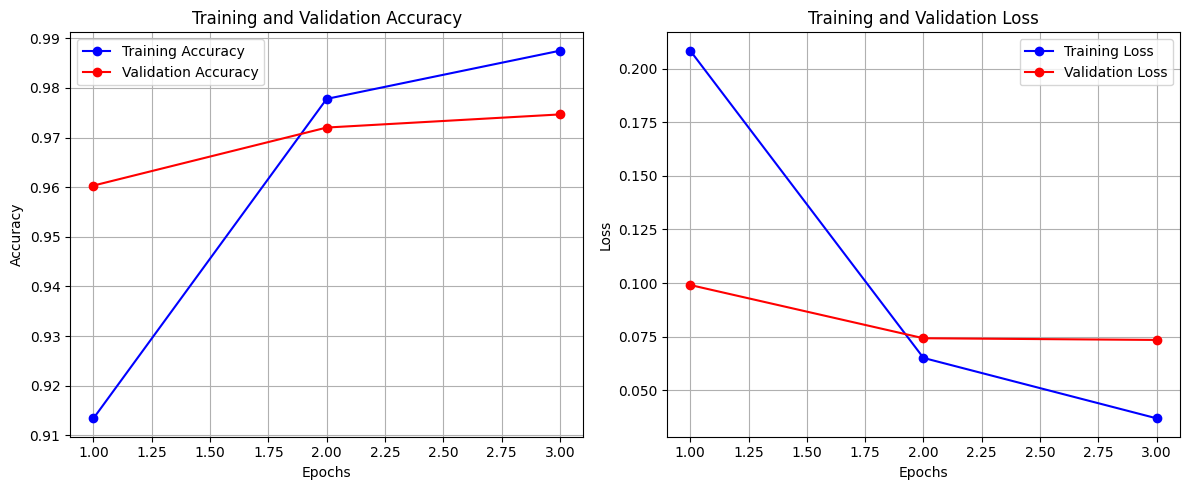

In [ ]:
y_train = np.asarray(train_df['true'])
y_val = np.asarray(val_df['true'])

# Training the model
# Training the model and storing the history
history = model.fit(padded_train, y_train, batch_size = 64, validation_data=(padded_val, y_val), epochs = 3)


# Get the history data
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_accuracy) + 1)

# Plot Training and Validation Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracy, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------


281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Bidirectional LSTM Model Accuracy :  0.9706013363028954
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      4706
           1       0.96      0.98      0.97      4274

    accuracy                           0.97      8980
   macro avg       0.97      0.97      0.97      8980
weighted avg       0.97      0.97      0.97      8980



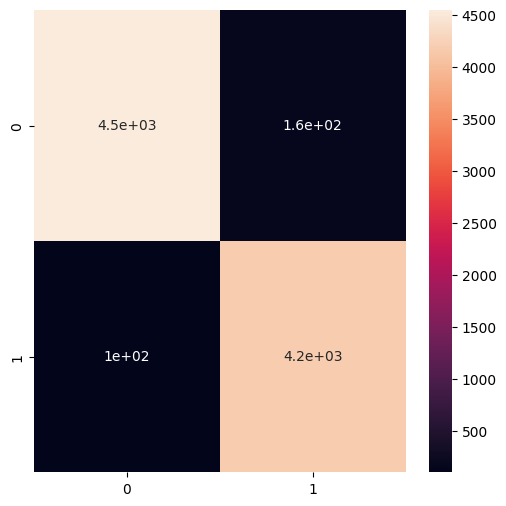

In [ ]:
# Making prediction
pred = model.predict(padded_test)
prediction = []
for i in pred:
    if i >= 0.5:
        prediction.append(1)
    else:
        prediction.append(0)

# Getting The Accuracy
y_test = np.asarray(test_df['true'])

accuracy = accuracy_score(list(y_test), prediction)

print("Bidirectional LSTM Model Accuracy : ", accuracy)

# Getting The Confusion Matrix
cm = confusion_matrix(list(y_test), prediction)
plt.figure(figsize = (6, 6))
sns.heatmap(cm, annot = True)

print(classification_report(y_test, prediction))


In [ ]:
embedding_vector_features = 40
model = Sequential()
model.add(Embedding(total_words, embedding_vector_features))

model.add(Dropout(0.5))

model.add(Conv1D(32, 5, activation='relu'))
model.add(MaxPool1D())

model.add(Conv1D(32, 5, activation='relu'))
model.add(MaxPool1D())

model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.build(input_shape=(None, padded_train.shape[1]))

print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 42, 40)         │       766,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 42, 40)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 38, 32)         │         6,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 15, 32)         │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        49,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 828,337 (3.16 MB)

 Trainable params: 828,337 (3.16 MB)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/3
449/449 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.8254 - loss: 0.3353 - val_accuracy: 0.9638 - val_loss: 0.0956
Epoch 2/3
449/449 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9781 - loss: 0.0655 - val_accuracy: 0.9734 - val_loss: 0.0751
Epoch 3/3
449/449 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9886 - loss: 0.0331 - val_accuracy: 0.9720 - val_loss: 0.0785


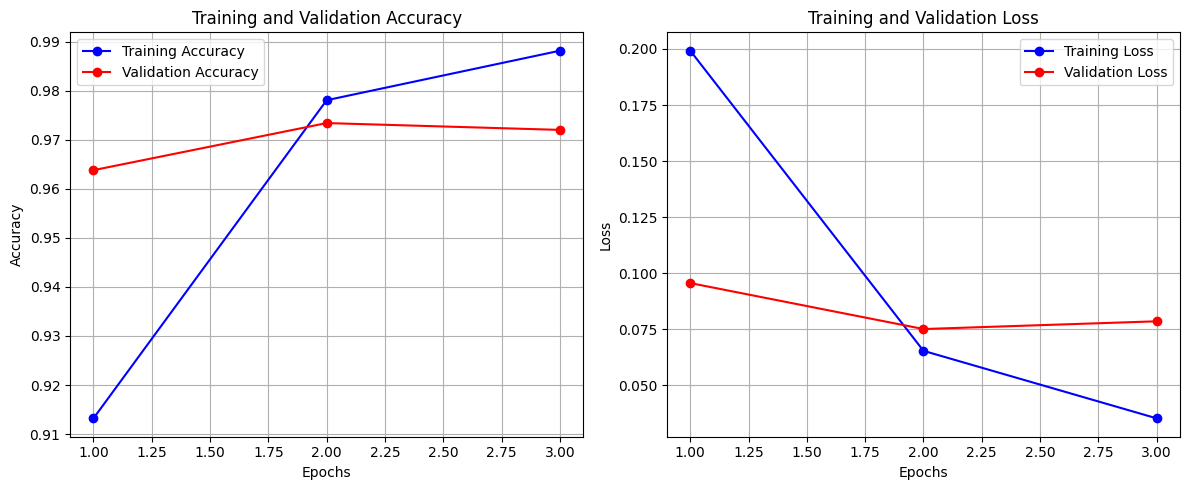

In [ ]:
y_train = np.asarray(train_df['true'])
y_val = np.asarray(val_df['true'])

# Training the model
# Training the model and storing the history
history = model.fit(padded_train, y_train, batch_size = 64, validation_data=(padded_val, y_val), epochs = 3)


# Get the history data
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_accuracy) + 1)

# Plot Training and Validation Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracy, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --------------------------------------------------------------------------



281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
CNN Model Accuracy :  0.9710467706013363
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      4706
           1       0.96      0.98      0.97      4274

    accuracy                           0.97      8980
   macro avg       0.97      0.97      0.97      8980
weighted avg       0.97      0.97      0.97      8980



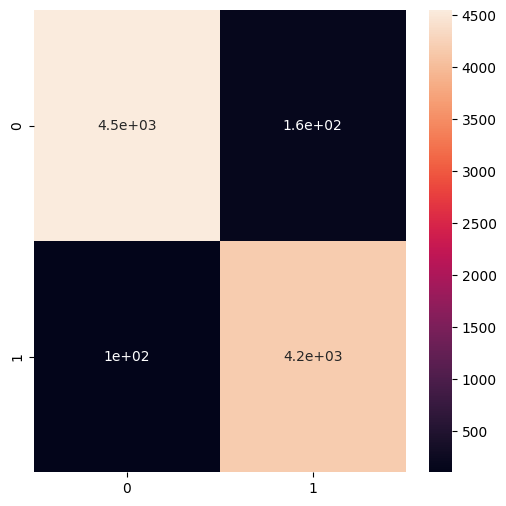

In [ ]:
# Making prediction
pred = model.predict(padded_test)
prediction = []
for i in pred:
    if i >= 0.5:
        prediction.append(1)
    else:
        prediction.append(0)

# Getting The Accuracy
y_test = np.asarray(test_df['true'])

accuracy = accuracy_score(list(y_test), prediction)

print("CNN Model Accuracy : ", accuracy)


# Getting The Confusion Matrix
cm = confusion_matrix(list(y_test), prediction)
plt.figure(figsize = (6, 6))
sns.heatmap(cm, annot = True)

print(classification_report(y_test, prediction))

In [ ]:
# manually testing
def predict_news_cnn_bilstm(news_title):
    # Preprocess the input title
    cleaned_title = preprocess(news_title)
    # Convert to sequence and pad
    sequence = tokenizer.texts_to_sequences([cleaned_title])
    padded_sequence = pad_sequences(sequence, maxlen=42, padding='post', truncating='post')
    # Predict
    prediction = model.predict(padded_sequence)
    # Return class label
    if prediction[0] >= 0.5:
        return "True News"
    else:
        return "Fake News"

# Make a prediction
for i in range(2):
    # Get input from the user inside the loop
    user_input = input(f"Enter a news title (Prediction {i+1} of 2): ")
    result = predict_news_cnn_bilstm(user_input)
    print(f"The news title is likely: {result}")

Enter a news title (Prediction 1 of 2): "I demand another 22 rejected Tories before I join Reform"
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
The news title is likely: Fake News
Enter a news title (Prediction 2 of 2): Charlie Kirk suspect confessed in hidden note to roommate, prosecutors allege
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
The news title is likely: True News
